<a href="https://colab.research.google.com/github/NehaSajjanar23/6thSem-ML-Lab/blob/main/1BM23CS209_Lab_6_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
diabetes = pd.read_csv("diabetes.csv")

# Features and target
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# Results
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.6883116883116883

Confusion Matrix
 [[79 20]
 [28 27]]


Best K: 11
Accuracy: 0.7540983606557377

Classification Report
               precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



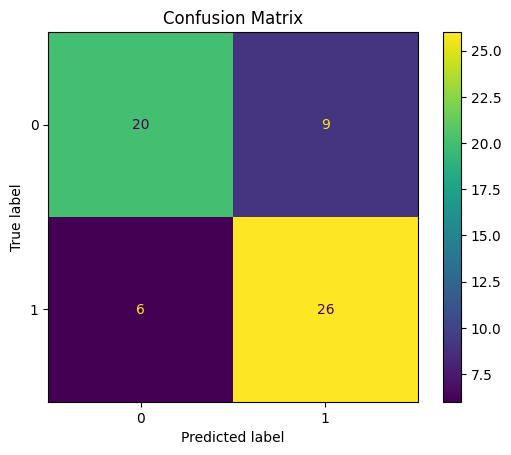

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load dataset
heart = pd.read_csv("heart.csv")

# Features and target
X = heart.drop("target", axis=1)
y = heart["target"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scores = []

# Try different K values
for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

best_k = scores.index(max(scores)) + 1
print("Best K:", best_k)

# Train model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report\n", classification_report(y_test, y_pred))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Best K value: 1
Accuracy Score: 1.0

Confusion Matrix
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



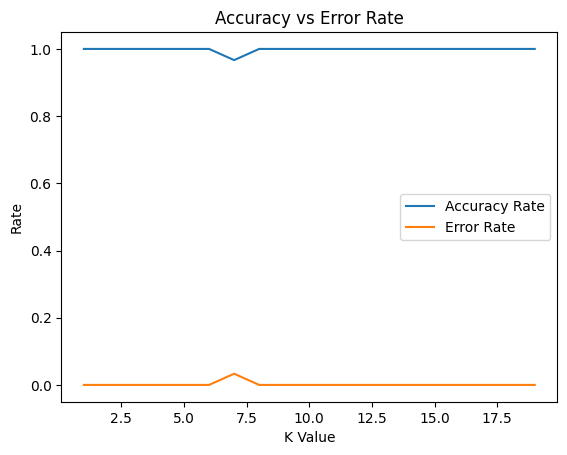

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = pd.read_csv("iris.csv")

# Convert species (text) to numeric
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])

# Features and target
X = iris.drop('species', axis=1)
y = iris['species']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

accuracy_rate = []
error_rate = []

# Try different K values
for k in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy_rate.append(acc)
    error_rate.append(1-acc)

# Find best K
best_k = accuracy_rate.index(max(accuracy_rate)) + 1
print("Best K value:", best_k)

# Train final model
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# Results
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))

# Plot accuracy and error rate
plt.plot(range(1,20), accuracy_rate, label="Accuracy Rate")
plt.plot(range(1,20), error_rate, label="Error Rate")

plt.xlabel("K Value")
plt.ylabel("Rate")
plt.title("Accuracy vs Error Rate")
plt.legend()

plt.show()